# AgroPlus - Modelo L3 No_apto (CRISP-DM)

Notebook dedicado al **modelo L3**: clasificador binario que decide si un pixel
es **No_apto para la agricultura** en Cundinamarca.

## Jerarquía de modelos AgroPlus

| Nivel | Modelo | Etiqueta | Confianza |
|-------|--------|----------|-----------|
| L2 | LLP-Co (18 cultivos EVA) | etiqueta débil municipal | 0.3-0.7 |
| **L3** | **Este modelo — No_apto** | proxy SIPRA + NDVI | 0.4 |

## Proxy de etiquetado L3

Un pixel se marca `No_apto` en la vista minable si cumple **alguna** de:
- **SIPRA**: >=3 capas de aptitud declaran el pixel "No apta" (98% de los casos)
- **NDVI_max < 0.15**: suelo desnudo/roca confirmado espectralmente (2% de los casos)

El objetivo del modelo es **aprender ese patrón** a partir de features ambientales,
para poder inferir sobre pixels nuevos donde el proxy no existe.

## Estrategia de modelado

- **Clasificacion binaria**: No_apto (1) vs Apto (0)
- **Features**: 33 features
- **Split temporal**: train 2020A-2022B | valid 2023A-2023B | test 2024A
- **Modelo**: XGBoost con `scale_pos_weight` para desbalance 14.4/85.6
- **Explicabilidad**: SHAP (beeswarm + dependence plots)
- **Umbral**: optimizado por F1 en validacion

---
## 1. Instalacion de dependencias

In [1]:
# Instalar dependencias si faltan
import subprocess, sys

pkgs = ["xgboost", "shap", "scikit-learn", "pyarrow", "pandas",
        "matplotlib", "seaborn", "joblib", "optuna"]
for p in pkgs:
    try:
        __import__(p.replace("-","_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])

print("Dependencias OK")


Dependencias OK


c:\Users\andres\anaconda3\envs\agroplus\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib, time
from pathlib import Path

import pyarrow.parquet as pq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
)
from sklearn.impute import SimpleImputer
import xgboost as xgb

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP no disponible — se omiten graficos de explicabilidad")

sns.set_theme(style="whitegrid", palette="muted")
print("Imports OK")


Imports OK


---
## 3. Configuracion

In [3]:
# === Rutas ===
DATA_DIR  = Path("../vista_minable")
CKPT_DIR  = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

PARQUET_PATH = DATA_DIR / "vista_minable_full.parquet"
CKPT_PATH    = CKPT_DIR / "l3_noapto.joblib"

# === Split temporal ===
SEMESTRES_TRAIN = ["2020A","2020B","2021A","2021B","2022A","2022B"]
SEMESTRES_VALID = ["2023A","2023B"]
SEMESTRES_TEST  = ["2024A"]

# === Features L3 (base L2 + ndvi_max + elevacion) ===
FEATURE_COLS = [
    # Topografia
    "elevacion", "pendiente", "twi", "piso_termico",
    "aspecto_sin", "aspecto_cos",
    # Clima
    "temperatura_media", "humedad_media", "chirps_acum",
    "amplitud_termica", "anomalia_precip", "indice_aridez",
    # Suelo SoilGrids
    "sg_phh2o", "sg_soc", "sg_nitrogen", "sg_cec",
    "sg_bdod", "sg_clay", "sg_sand", "sg_silt",
    # Suelo IGAC
    "igac_fertilidad", "igac_ph", "igac_potasio", "igac_vocacion",
    # Indice fertilidad derivado
    "indice_fertilidad",
    # Sentinel-2 / NDVI
    "ndvi_max", "ndvi_mean_temporal", "ndvi_sigma_temporal", "ndvi_integral",
    "s2_gndvi_max", "s2_msavi_max", "s2_bsi_max", "s2_bsi_std",
]

SEED    = 42
TARGET  = "y_noapto"
POS_LABEL_FUENTE = "noapto_proxy"

print(f"Features: {len(FEATURE_COLS)}")
print(f"Train semestres: {SEMESTRES_TRAIN}")
print(f"Valid semestres: {SEMESTRES_VALID}")
print(f"Test  semestres: {SEMESTRES_TEST}")


Features: 33
Train semestres: ['2020A', '2020B', '2021A', '2021B', '2022A', '2022B']
Valid semestres: ['2023A', '2023B']
Test  semestres: ['2024A']


---
## 4. Comprension de los datos

In [4]:
# === Carga selectiva de columnas ===
load_cols = FEATURE_COLS + ["semestre", "fuente", "confianza", "cod_mun",
                             "cultivo", "x", "y"]
print(f"Cargando {PARQUET_PATH} ...")
t0 = time.time()
df_raw = pq.read_table(PARQUET_PATH, columns=load_cols).to_pandas()
print(f"Vista minable cargada: {len(df_raw):,} filas x {df_raw.shape[1]} cols ({time.time()-t0:.1f}s)")
print()

# === Definir target binario ===
df_raw[TARGET] = (df_raw["fuente"] == POS_LABEL_FUENTE).astype(np.int8)

# === Distribucion de clases ===
n_pos = df_raw[TARGET].sum()
n_neg = len(df_raw) - n_pos
ratio = n_neg / n_pos
print(f"Clase 1 (No_apto): {n_pos:>10,}  ({100*n_pos/len(df_raw):.1f}%)")
print(f"Clase 0 (Apto)   : {n_neg:>10,}  ({100*n_neg/len(df_raw):.1f}%)")
print(f"scale_pos_weight recomendado: {ratio:.2f}")
print()

# === Fuentes de etiquetado ===
print("Distribucion por fuente:")
print(df_raw.fuente.value_counts().to_string())
print()

# === Semestres ===
print("Filas por semestre:")
print(df_raw.groupby("semestre").size().to_string())


Cargando ..\vista_minable\vista_minable_full.parquet ...
Vista minable cargada: 4,165,215 filas x 40 cols (0.8s)

Clase 1 (No_apto):    600,869  (14.4%)
Clase 0 (Apto)   :  3,564,346  (85.6%)
scale_pos_weight recomendado: 5.93

Distribucion por fuente:
fuente
eva_municipal    2998317
noapto_proxy      600869
monitoreo         566029

Filas por semestre:
semestre
2020A    460459
2020B    460459
2021A    462520
2021B    462520
2022A    463632
2022B    463932
2023A    463422
2023B    464487
2024A    463784


In [5]:
# === Exploracion de features: No_apto vs Apto ===
noapto = df_raw[df_raw[TARGET] == 1]
apto   = df_raw[df_raw[TARGET] == 0]

print(f"\nMediana por clase (No_apto vs Apto):")
print(f"{'Feature':<28} {'No_apto':>10} {'Apto':>10} {'Diff':>10}")
print("-" * 62)
for f in FEATURE_COLS:
    mn = np.nanmedian(noapto[f].values)
    ma = np.nanmedian(apto[f].values)
    print(f"  {f:<26} {mn:>10.3f} {ma:>10.3f} {mn-ma:>+10.3f}")



Mediana por clase (No_apto vs Apto):
Feature                         No_apto       Apto       Diff
--------------------------------------------------------------
  elevacion                    2436.978   2703.026   -266.048
  pendiente                      18.799     12.227     +6.572
  twi                             3.038      3.136     -0.099
  piso_termico                    2.000      2.000     +0.000
  aspecto_sin                     0.161     -0.149     +0.310
  aspecto_cos                    -0.108     -0.251     +0.143
  temperatura_media               0.265     -3.256     +3.521
  humedad_media                  75.862     75.862     +0.000
  chirps_acum                   737.315    607.691   +129.625
  amplitud_termica                2.509      2.220     +0.290
  anomalia_precip                -0.121     -0.137     +0.017
  indice_aridez                   4.655      4.480     +0.175
  sg_phh2o                        5.400      5.500     -0.100
  sg_soc                       

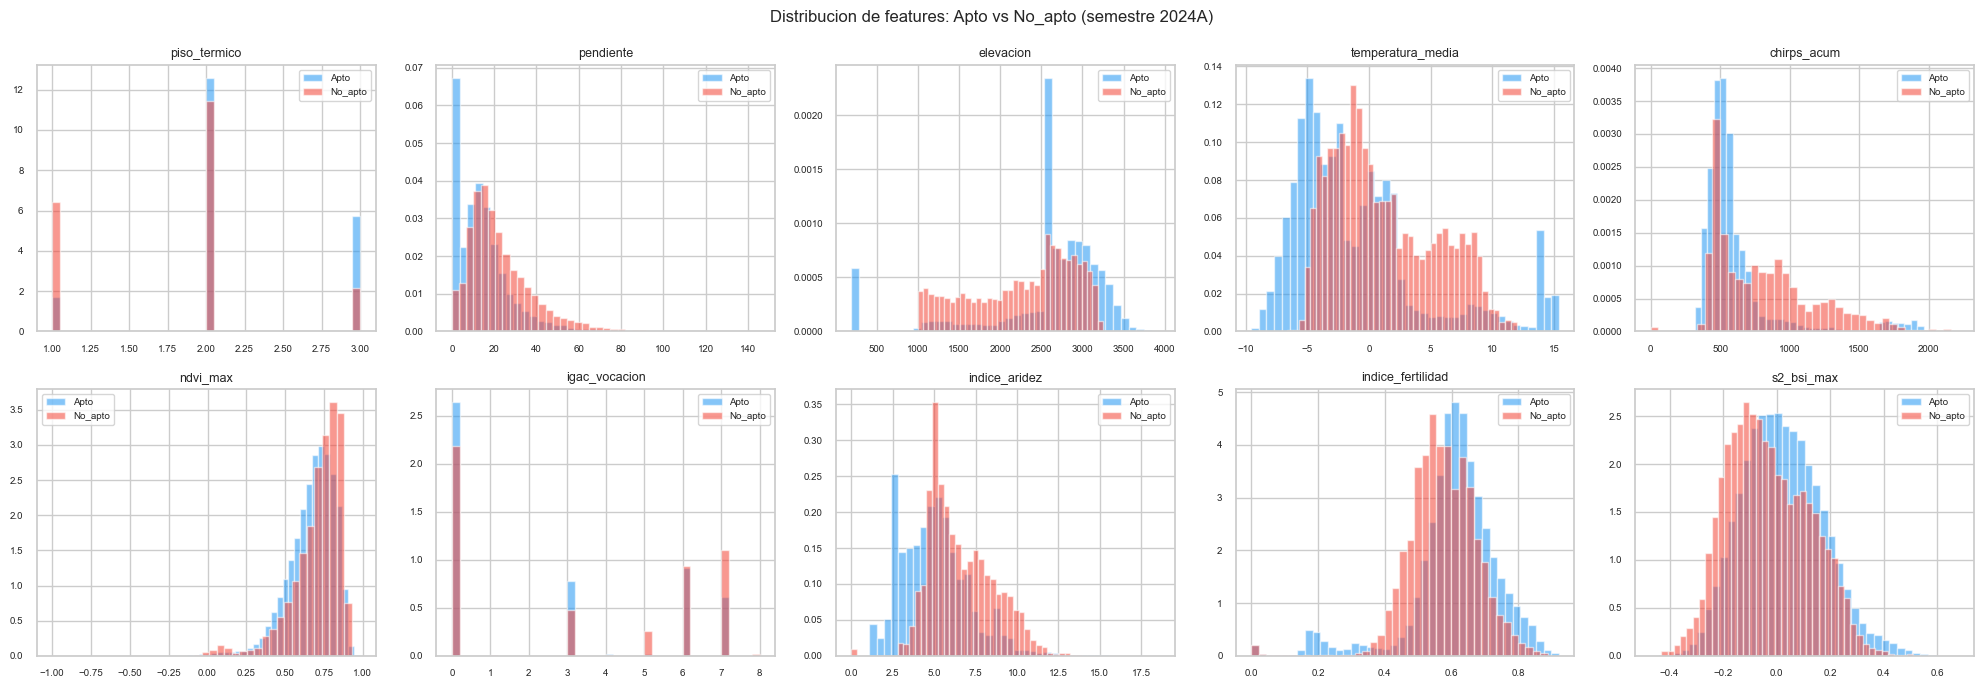

In [6]:
# === Visualizacion EDA: top features discriminantes ===
top_features = ["piso_termico","pendiente","elevacion",
                "temperatura_media","chirps_acum","ndvi_max",
                "igac_vocacion","indice_aridez","indice_fertilidad",
                "s2_bsi_max"]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

sem = "2024A"
sub = df_raw[df_raw.semestre == sem].sample(min(40000, len(df_raw)), random_state=SEED)

for i, f in enumerate(top_features):
    ax = axes[i]
    for lbl, color, name in [(0, "#2196F3", "Apto"), (1, "#F44336", "No_apto")]:
        vals = sub[sub[TARGET]==lbl][f].dropna().values
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(f, fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle(f"Distribucion de features: Apto vs No_apto (semestre {sem})", fontsize=12)
plt.tight_layout()
plt.show()


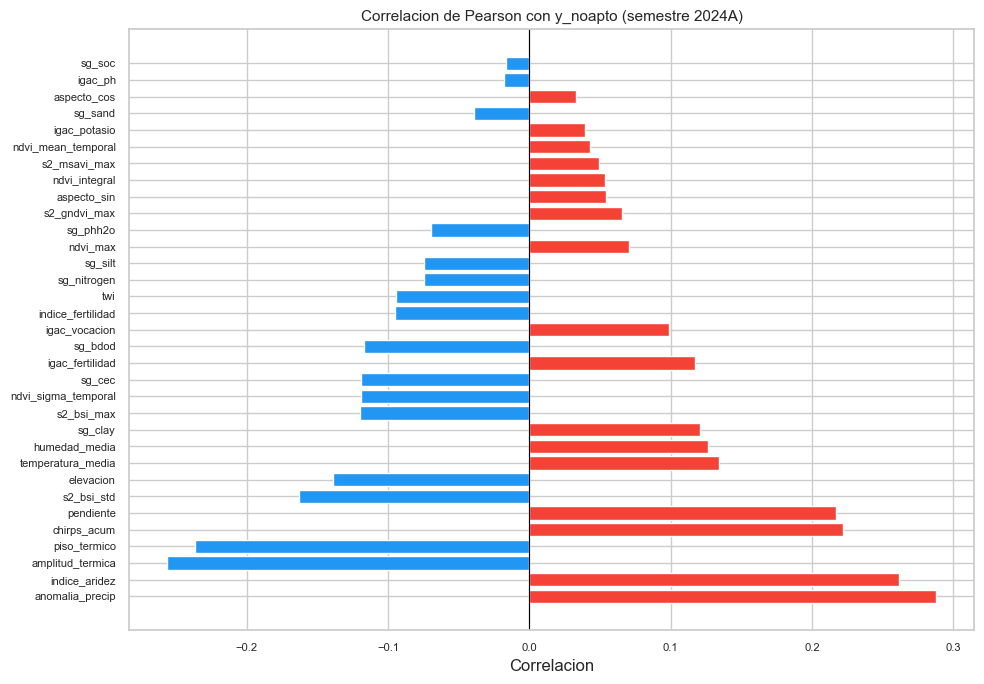


Top 10 correlaciones absolutas:
anomalia_precip      0.287491
indice_aridez        0.261393
amplitud_termica     0.255981
piso_termico         0.236710
chirps_acum          0.221781
pendiente            0.216701
s2_bsi_std           0.162590
elevacion            0.139012
temperatura_media    0.134386
humedad_media        0.126379


In [7]:
# === Correlacion con el target ===
sem_plot = "2024A"
sub_c = df_raw[df_raw.semestre == sem_plot][FEATURE_COLS + [TARGET]].copy()
corrs = sub_c.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#F44336" if v > 0 else "#2196F3" for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Correlacion de Pearson con y_noapto (semestre {sem_plot})", fontsize=11)
ax.set_xlabel("Correlacion")
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

print("\nTop 10 correlaciones absolutas:")
print(corrs.abs().head(10).to_string())


---
## 5. Preparacion de datos

In [8]:
# === Split temporal ===
train_mask = df_raw["semestre"].isin(SEMESTRES_TRAIN)
valid_mask = df_raw["semestre"].isin(SEMESTRES_VALID)
test_mask  = df_raw["semestre"].isin(SEMESTRES_TEST)

df_train = df_raw[train_mask].copy()
df_valid = df_raw[valid_mask].copy()
df_test  = df_raw[test_mask].copy()

print("Split temporal:")
for name, df in [("Train", df_train), ("Valid", df_valid), ("Test", df_test)]:
    n = len(df)
    pos = df[TARGET].sum()
    print(f"  {name}: {n:>8,} filas | No_apto={pos:>7,} ({100*pos/n:.1f}%)")

print()
# === Matrices de features ===
X_train = df_train[FEATURE_COLS].values.astype(np.float32)
X_valid = df_valid[FEATURE_COLS].values.astype(np.float32)
X_test  = df_test [FEATURE_COLS].values.astype(np.float32)

y_train = df_train[TARGET].values
y_valid = df_valid[TARGET].values
y_test  = df_test [TARGET].values

w_train = df_train["confianza"].values.astype(np.float32)

print(f"X_train: {X_train.shape}  nulos: {np.isnan(X_train).sum():,}")
print(f"X_valid: {X_valid.shape}  nulos: {np.isnan(X_valid).sum():,}")
print(f"X_test:  {X_test.shape}   nulos: {np.isnan(X_test).sum():,}")


Split temporal:
  Train: 2,773,522 filas | No_apto=403,017 (14.5%)
  Valid:  927,909 filas | No_apto=131,341 (14.2%)
  Test:  463,784 filas | No_apto= 66,511 (14.3%)

X_train: (2773522, 33)  nulos: 299,560
X_valid: (927909, 33)  nulos: 87,366
X_test:  (463784, 33)   nulos: 37,568


In [9]:
# === Imputacion (mediana sobre train) ===
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_valid = imputer.transform(X_valid)
X_test  = imputer.transform(X_test)

print("Imputacion completada (mediana sobre train)")
print(f"  nulos post-imputacion train: {np.isnan(X_train).sum()}")


Imputacion completada (mediana sobre train)
  nulos post-imputacion train: 0


---
## 6. Modelo XGBoost

In [10]:
# === Parametros base (calibrados para este dataset) ===
# scale_pos_weight compensa el desbalance 85.6% / 14.4%
n_pos_tr = y_train.sum()
n_neg_tr = len(y_train) - n_pos_tr
SPW = n_neg_tr / n_pos_tr
print(f"scale_pos_weight = {SPW:.2f}")

PARAMS = dict(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_weight  = 10,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = SPW,
    random_state      = SEED,
    n_jobs            = -1,
    tree_method       = "hist",
    eval_metric       = ["logloss", "auc"],
    early_stopping_rounds = 30,
)

model = xgb.XGBClassifier(**PARAMS)

print("Entrenando XGBoost L3...")
t0 = time.time()
model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50,
)
print(f"\nEntrenamiento completado en {time.time()-t0:.1f}s")
print(f"Mejor iteracion: {model.best_iteration} | Mejor AUC valid: {model.best_score:.4f}")


scale_pos_weight = 5.88
Entrenando XGBoost L3...
[0]	validation_0-logloss:0.50864	validation_0-auc:0.88290
[41]	validation_0-logloss:0.44761	validation_0-auc:0.86295

Entrenamiento completado en 8.9s
Mejor iteracion: 11 | Mejor AUC valid: 0.9017


---
## 7. Evaluacion del modelo

In [11]:
# === Probabilidades predichas ===
p_valid = model.predict_proba(X_valid)[:, 1]
p_test  = model.predict_proba(X_test )[:, 1]

# === Metricas de ranking ===
auc_roc_va  = roc_auc_score(y_valid, p_valid)
auc_pr_va   = average_precision_score(y_valid, p_valid)
auc_roc_te  = roc_auc_score(y_test,  p_test )
auc_pr_te   = average_precision_score(y_test,  p_test )

print("=" * 50)
print(f"{'Metrica':<20} {'Valid':>10} {'Test':>10}")
print("-" * 50)
print(f"  {'AUC-ROC':<18} {auc_roc_va:>10.4f} {auc_roc_te:>10.4f}")
print(f"  {'AUC-PR':<18} {auc_pr_va:>10.4f} {auc_pr_te:>10.4f}")
print("=" * 50)


Metrica                   Valid       Test
--------------------------------------------------
  AUC-ROC                0.9017     0.8893
  AUC-PR                 0.6089     0.6021


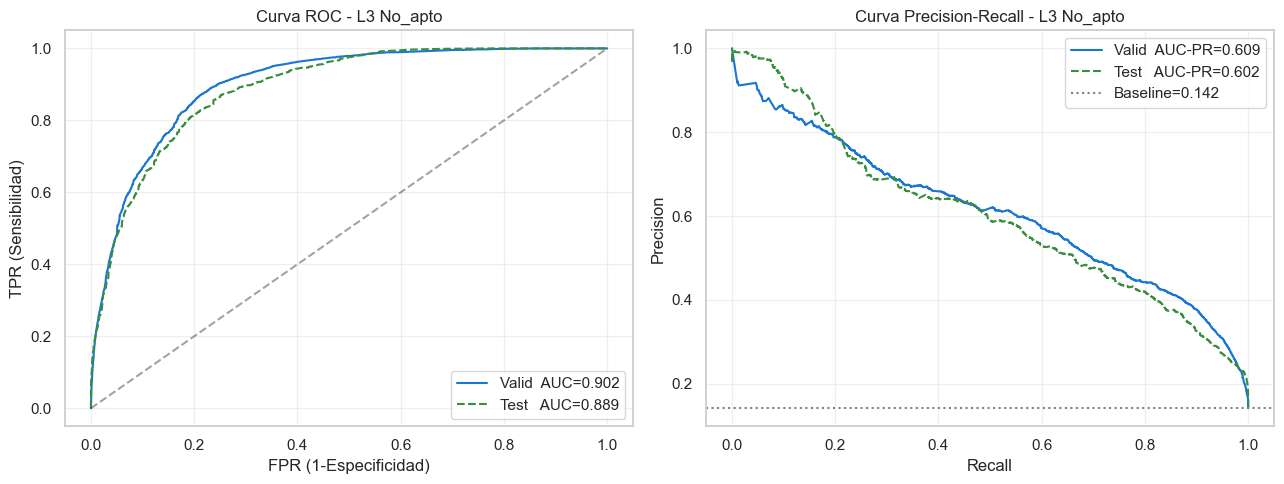

In [12]:
# === Curvas ROC y PR ===
fpr_va, tpr_va, _ = roc_curve(y_valid, p_valid)
fpr_te, tpr_te, _ = roc_curve(y_test,  p_test)
prec_va, rec_va, thr_pr = precision_recall_curve(y_valid, p_valid)
prec_te, rec_te, _      = precision_recall_curve(y_test,  p_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(fpr_va, tpr_va, label=f"Valid  AUC={auc_roc_va:.3f}", color="#1976D2")
ax.plot(fpr_te, tpr_te, label=f"Test   AUC={auc_roc_te:.3f}", color="#388E3C", linestyle="--")
ax.plot([0,1],[0,1],"k--",alpha=0.4)
ax.set_xlabel("FPR (1-Especificidad)"); ax.set_ylabel("TPR (Sensibilidad)")
ax.set_title("Curva ROC - L3 No_apto"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
baseline = y_valid.mean()
ax.plot(rec_va, prec_va, label=f"Valid  AUC-PR={auc_pr_va:.3f}", color="#1976D2")
ax.plot(rec_te, prec_te, label=f"Test   AUC-PR={auc_pr_te:.3f}", color="#388E3C", linestyle="--")
ax.axhline(baseline, color="gray", linestyle=":", label=f"Baseline={baseline:.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall - L3 No_apto"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


Umbral optimo por F1: 0.4716
  Precision @ umbral: 0.5573
  Recall    @ umbral: 0.6331
  F1        @ umbral: 0.5928


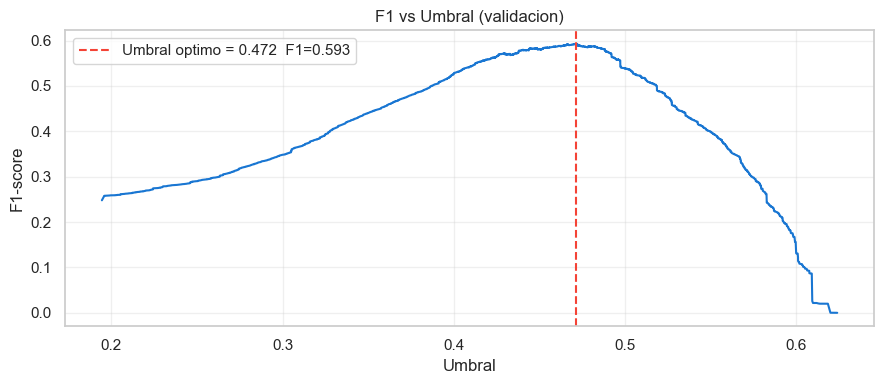

In [13]:
# === Optimizar umbral por F1 en validacion ===
thresholds = thr_pr  # ya calculados en precision_recall_curve
f1s = 2 * prec_va[:-1] * rec_va[:-1] / np.maximum(prec_va[:-1] + rec_va[:-1], 1e-9)
best_idx = np.argmax(f1s)
THRESHOLD = float(thresholds[best_idx])
print(f"Umbral optimo por F1: {THRESHOLD:.4f}")
print(f"  Precision @ umbral: {prec_va[best_idx]:.4f}")
print(f"  Recall    @ umbral: {rec_va[best_idx]:.4f}")
print(f"  F1        @ umbral: {f1s[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1s, color="#1976D2")
ax.axvline(THRESHOLD, color="#F44336", linestyle="--",
           label=f"Umbral optimo = {THRESHOLD:.3f}  F1={f1s[best_idx]:.3f}")
ax.set_xlabel("Umbral"); ax.set_ylabel("F1-score")
ax.set_title("F1 vs Umbral (validacion)"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


Metricas con umbral=0.4716  [Valid]
              precision    recall  f1-score   support

        Apto      0.938     0.917     0.927    796568
     No_apto      0.557     0.633     0.593    131341

    accuracy                          0.877    927909
   macro avg      0.748     0.775     0.760    927909
weighted avg      0.884     0.877     0.880    927909



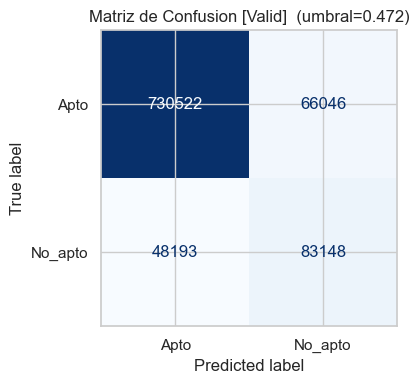

Metricas con umbral=0.4716  [Test]
              precision    recall  f1-score   support

        Apto      0.891     0.978     0.933    397273
     No_apto      0.686     0.286     0.403     66511

    accuracy                          0.879    463784
   macro avg      0.788     0.632     0.668    463784
weighted avg      0.862     0.879     0.857    463784



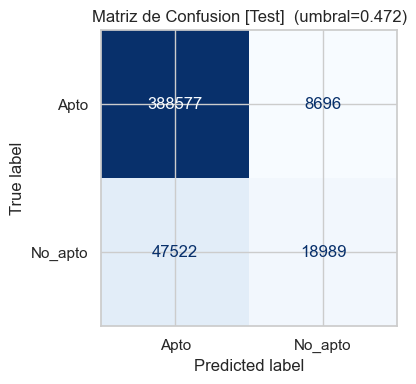

In [14]:
# === Metricas con umbral optimo ===
for split_name, y_true, p_pred in [("Valid", y_valid, p_valid), ("Test", y_test, p_test)]:
    y_pred = (p_pred >= THRESHOLD).astype(int)
    print(f"{'='*55}")
    print(f"Metricas con umbral={THRESHOLD:.4f}  [{split_name}]")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                 target_names=["Apto","No_apto"], digits=3))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Apto","No_apto"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Matriz de Confusion [{split_name}]  (umbral={THRESHOLD:.3f})")
    plt.tight_layout(); plt.show()


---
## 8. Importancia de features

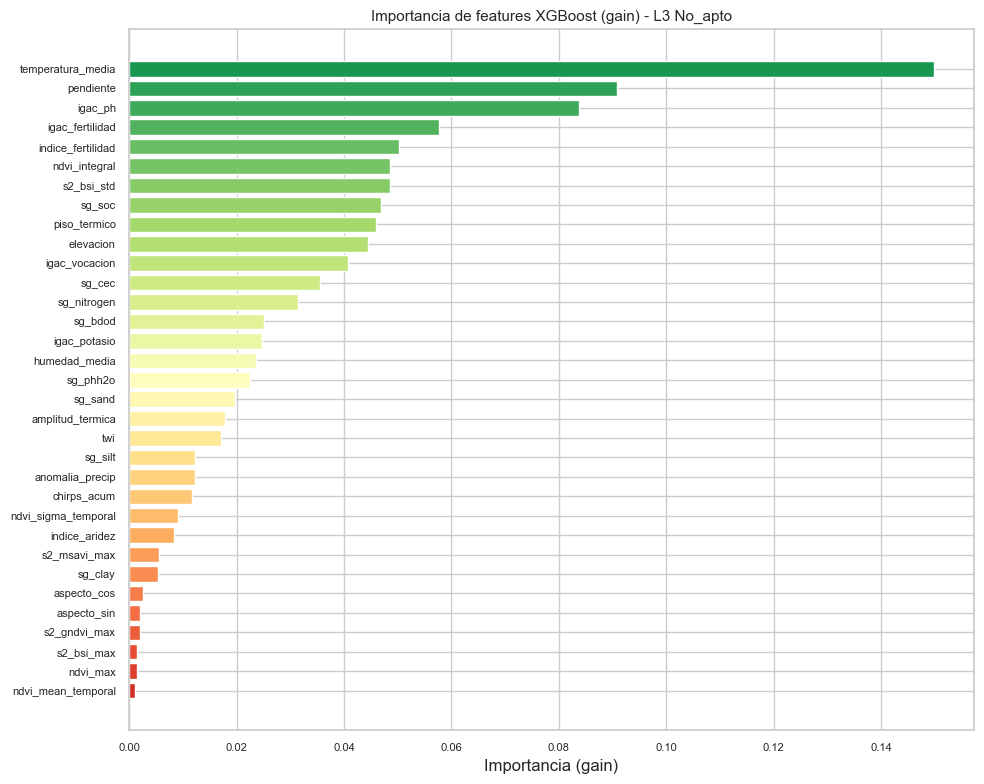

Top 10 features:
temperatura_media    0.149771
pendiente            0.090848
igac_ph              0.083738
igac_fertilidad      0.057625
indice_fertilidad    0.050212
ndvi_integral        0.048527
s2_bsi_std           0.048520
sg_soc               0.046940
piso_termico         0.045900
elevacion            0.044465


In [15]:
# === Importancia nativa XGBoost (ganancia) ===
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(feat_imp)))
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1])
ax.set_title("Importancia de features XGBoost (gain) - L3 No_apto", fontsize=11)
ax.set_xlabel("Importancia (gain)")
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

print("Top 10 features:")
print(feat_imp.head(10).to_string())


Calculando valores SHAP (puede tardar ~1-2 min)...
SHAP calculado en 0.1s


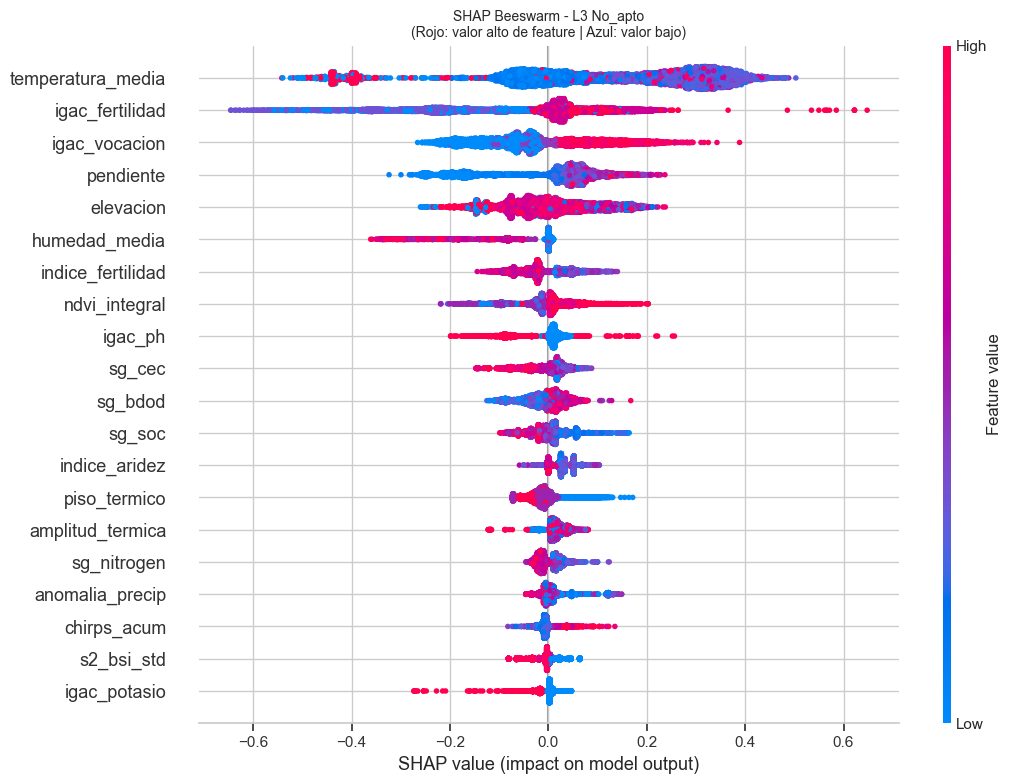

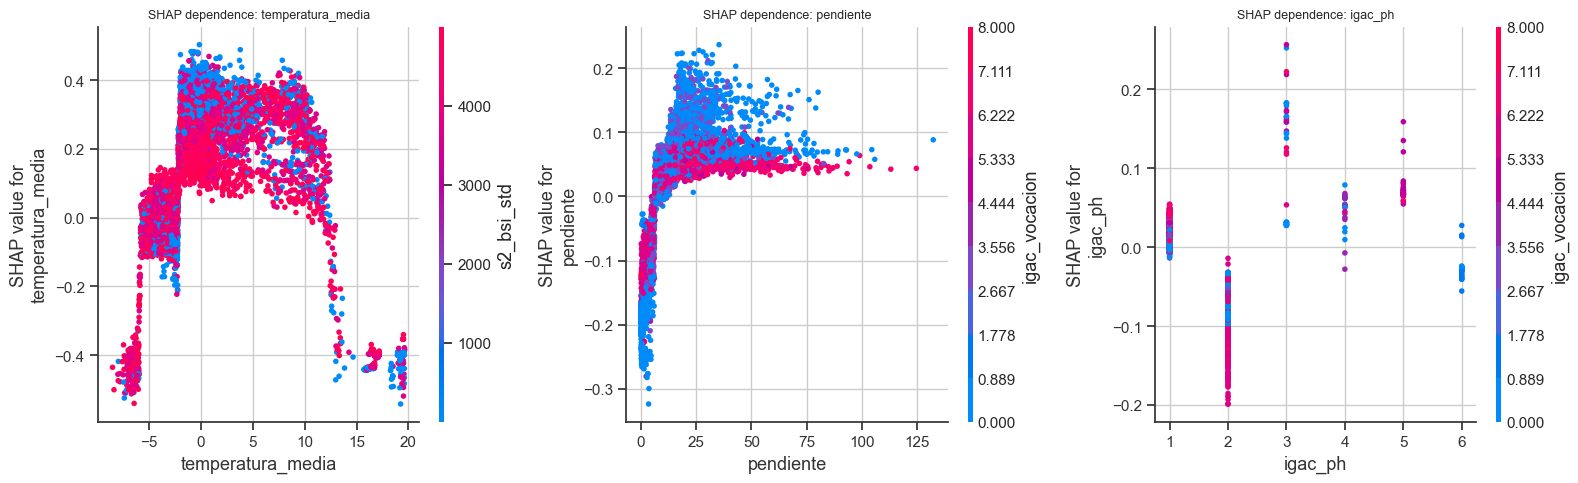

In [16]:
# === SHAP: explicabilidad local y global ===
if HAS_SHAP:
    print("Calculando valores SHAP (puede tardar ~1-2 min)...")
    t0 = time.time()

    # Muestra representativa de validacion para SHAP
    idx_sample = np.random.RandomState(SEED).choice(len(X_valid),
                                                    size=min(8000, len(X_valid)),
                                                    replace=False)
    X_shap = X_valid[idx_sample]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
    print(f"SHAP calculado en {time.time()-t0:.1f}s")

    # Beeswarm (impacto global)
    fig, ax = plt.subplots(figsize=(11, 8))
    shap.summary_plot(shap_values, X_shap,
                      feature_names=FEATURE_COLS,
                      max_display=20, show=False, plot_size=None)
    plt.title("SHAP Beeswarm - L3 No_apto\n"
              "(Rojo: valor alto de feature | Azul: valor bajo)", fontsize=10)
    plt.tight_layout(); plt.show()

    # Top 3 dependence plots
    top3 = feat_imp.head(3).index.tolist()
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for i, feat in enumerate(top3):
        fi = FEATURE_COLS.index(feat)
        shap.dependence_plot(fi, shap_values, X_shap,
                             feature_names=FEATURE_COLS,
                             ax=axes[i], show=False)
        axes[i].set_title(f"SHAP dependence: {feat}", fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("SHAP no disponible. Instala con: pip install shap")


---
## 9. Analisis de errores

In [17]:
# === Falsos positivos y negativos: perfil de features ===
y_pred_va = (p_valid >= THRESHOLD).astype(int)

tp_mask = (y_valid == 1) & (y_pred_va == 1)
fp_mask = (y_valid == 0) & (y_pred_va == 1)
fn_mask = (y_valid == 1) & (y_pred_va == 0)
tn_mask = (y_valid == 0) & (y_pred_va == 0)

print(f"  TP: {tp_mask.sum():,}  TN: {tn_mask.sum():,}")
print(f"  FP: {fp_mask.sum():,}  FN: {fn_mask.sum():,}")
print()
print("Perfil de features en FP vs FN vs TP (mediana):")
print(f"{'Feature':<26} {'TP':>8} {'FP':>8} {'FN':>8}")
print("-" * 54)
feats_err = ["elevacion","pendiente","piso_termico","ndvi_max",
             "igac_vocacion","temperatura_media","chirps_acum","indice_fertilidad"]
for f in feats_err:
    fi = FEATURE_COLS.index(f)
    tp_val = np.nanmedian(X_valid[tp_mask, fi])
    fp_val = np.nanmedian(X_valid[fp_mask, fi])
    fn_val = np.nanmedian(X_valid[fn_mask, fi])
    print(f"  {f:<24} {tp_val:>8.2f} {fp_val:>8.2f} {fn_val:>8.2f}")


  TP: 83,148  TN: 730,522
  FP: 66,046  FN: 48,193

Perfil de features en FP vs FN vs TP (mediana):
Feature                          TP       FP       FN
------------------------------------------------------
  elevacion                 2227.64  2382.97  2658.30
  pendiente                   18.79    19.57    19.35
  piso_termico                 2.00     2.00     2.00
  ndvi_max                     0.75     0.76     0.75
  igac_vocacion                5.00     6.00     3.00
  temperatura_media            2.81     1.02     0.35
  chirps_acum                771.96   709.17   680.27
  indice_fertilidad            0.54     0.57     0.63


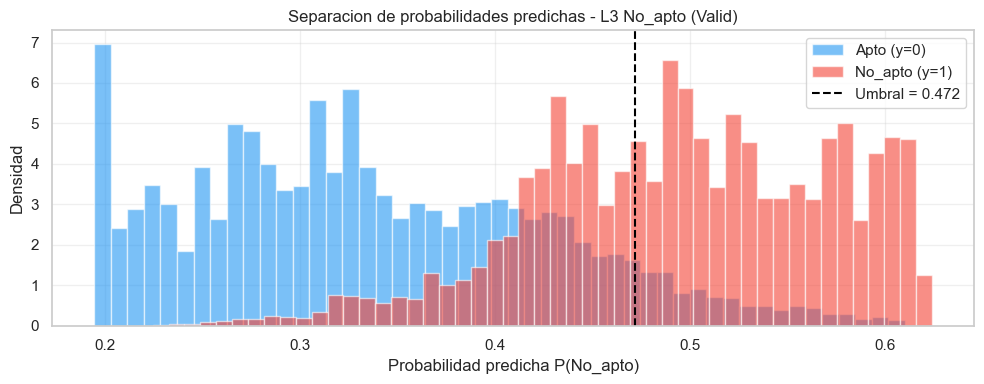

In [18]:
# === Distribucion de probabilidades predichas por clase real ===
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(p_valid[y_valid == 0], bins=50, alpha=0.6, color="#2196F3",
        label="Apto (y=0)", density=True)
ax.hist(p_valid[y_valid == 1], bins=50, alpha=0.6, color="#F44336",
        label="No_apto (y=1)", density=True)
ax.axvline(THRESHOLD, color="black", linestyle="--",
           label=f"Umbral = {THRESHOLD:.3f}")
ax.set_xlabel("Probabilidad predicha P(No_apto)")
ax.set_ylabel("Densidad")
ax.set_title("Separacion de probabilidades predichas - L3 No_apto (Valid)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 10. Modelo final y persistencia

In [19]:
# === Reentrenar sobre train+valid para el checkpoint final ===
X_trainval = np.vstack([X_train, X_valid])
y_trainval = np.concatenate([y_train, y_valid])
w_trainval = np.concatenate([
    w_train,
    df_valid["confianza"].values.astype(np.float32)
])

print("Reentrenando sobre train+valid con n_estimators optimo...")
t0 = time.time()
model_final = xgb.XGBClassifier(**{**PARAMS,
    "n_estimators": model.best_iteration + 1,
    "early_stopping_rounds": None,
})
model_final.fit(X_trainval, y_trainval, sample_weight=w_trainval)
print(f"Listo en {time.time()-t0:.1f}s")

# Metricas finales en test
p_test_final = model_final.predict_proba(X_test)[:, 1]
auc_f = roc_auc_score(y_test, p_test_final)
apr_f = average_precision_score(y_test, p_test_final)
f1_f  = f1_score(y_test, (p_test_final >= THRESHOLD).astype(int))
print(f"\n=== Metricas modelo final en TEST ===")
print(f"  AUC-ROC : {auc_f:.4f}")
print(f"  AUC-PR  : {apr_f:.4f}")
print(f"  F1      : {f1_f:.4f}  (umbral={THRESHOLD:.4f})")


Reentrenando sobre train+valid con n_estimators optimo...
Listo en 3.3s

=== Metricas modelo final en TEST ===
  AUC-ROC : 0.9312
  AUC-PR  : 0.6914
  F1      : 0.6618  (umbral=0.4716)


In [20]:
# === Guardar checkpoint ===
artifact = {
    "model":         model_final,
    "imputer":       imputer,
    "feature_cols":  FEATURE_COLS,
    "threshold":     THRESHOLD,
    "auc_roc_test":  float(auc_f),
    "auc_pr_test":   float(apr_f),
    "f1_test":       float(f1_f),
    "semestres_train": SEMESTRES_TRAIN,
    "semestres_valid": SEMESTRES_VALID,
    "semestres_test":  SEMESTRES_TEST,
    "scale_pos_weight": float(SPW),
    "n_features":    len(FEATURE_COLS),
    "n_estimators":  model.best_iteration + 1,
}

joblib.dump(artifact, CKPT_PATH, compress=3)
size_mb = CKPT_PATH.stat().st_size / 1e6
print(f"Checkpoint guardado: {CKPT_PATH}  ({size_mb:.1f} MB)")
print(f"  n_estimators : {model.best_iteration + 1}")
print(f"  features     : {len(FEATURE_COLS)}")
print(f"  threshold    : {THRESHOLD:.4f}")
print(f"  AUC-ROC test : {auc_f:.4f}")
print(f"  F1 test      : {f1_f:.4f}")


Checkpoint guardado: checkpoints\l3_noapto.joblib  (0.0 MB)
  n_estimators : 12
  features     : 33
  threshold    : 0.4716
  AUC-ROC test : 0.9312
  F1 test      : 0.6618


---
## 11. Funcion de inferencia L3

In [21]:
# === Funcion de inferencia reutilizable ===
def inferir_l3_noapto(df_pixeles, ckpt_path=None):
    # Retorna P(No_apto) para cada pixel en df_pixeles.
    import joblib
    from pathlib import Path
    if ckpt_path is None:
        ckpt_path = Path("checkpoints/l3_noapto.joblib")
    art = joblib.load(ckpt_path)
    X   = df_pixeles[art["feature_cols"]].values.astype(np.float32)
    X   = art["imputer"].transform(X)
    return art["model"].predict_proba(X)[:, 1]


# === Demo sobre el semestre de test ===
p_demo = inferir_l3_noapto(df_test)
y_demo = (p_demo >= artifact["threshold"]).astype(int)

print("Demo inferencia L3 sobre Test (2024A):")
print(f"  Pixeles: {len(p_demo):,}")
print(f"  P(No_apto) media  : {p_demo.mean():.4f}")
print(f"  P(No_apto) mediana: {np.median(p_demo):.4f}")
print(f"  Predichos No_apto : {y_demo.sum():,} ({100*y_demo.mean():.1f}%)")
print(f"  Real No_apto      : {y_test.sum():,} ({100*y_test.mean():.1f}%)")


Demo inferencia L3 sobre Test (2024A):
  Pixeles: 463,784
  P(No_apto) media  : 0.3203
  P(No_apto) mediana: 0.2834
  Predichos No_apto : 66,449 (14.3%)
  Real No_apto      : 66,511 (14.3%)


---
## 12. Mapa espacial de predicciones L3

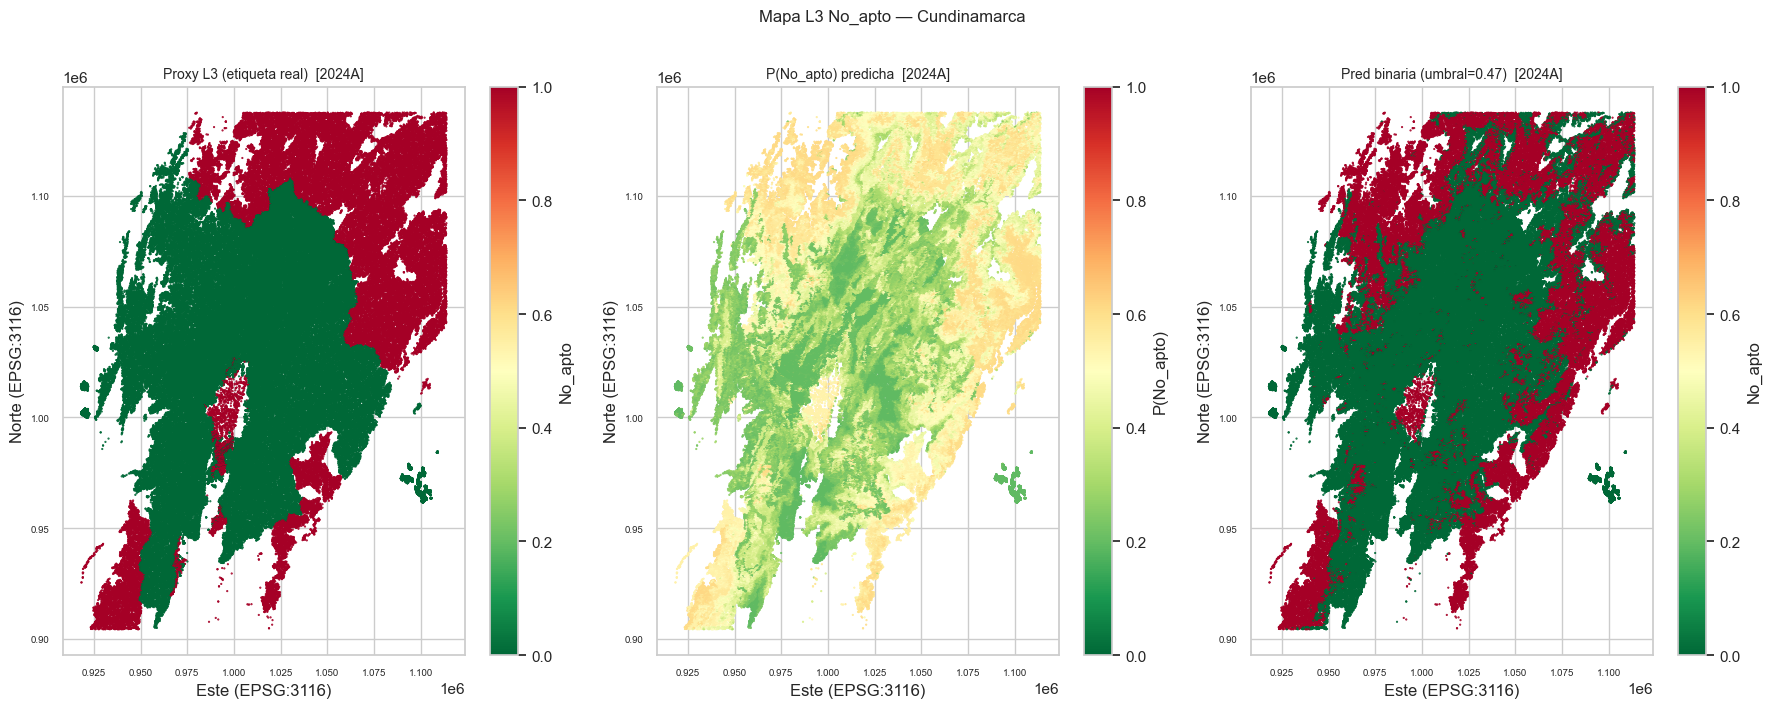

In [22]:
# === Mapa: probabilidad predicha vs etiqueta proxy ===
sem_map = "2024A"
df_map  = df_test[df_test.semestre == sem_map].copy()
df_map["p_noapto"] = inferir_l3_noapto(df_map)
df_map["pred"]     = (df_map["p_noapto"] >= artifact["threshold"]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Panel 1: Proxy (etiqueta original)
sc1 = axes[0].scatter(df_map.x, df_map.y,
                      c=df_map[TARGET].astype(float),
                      cmap="RdYlGn_r", s=0.3, vmin=0, vmax=1)
axes[0].set_title(f"Proxy L3 (etiqueta real)  [{sem_map}]", fontsize=10)
plt.colorbar(sc1, ax=axes[0], label="No_apto")

# Panel 2: Probabilidad predicha
sc2 = axes[1].scatter(df_map.x, df_map.y,
                      c=df_map["p_noapto"],
                      cmap="RdYlGn_r", s=0.3, vmin=0, vmax=1)
axes[1].set_title(f"P(No_apto) predicha  [{sem_map}]", fontsize=10)
plt.colorbar(sc2, ax=axes[1], label="P(No_apto)")

# Panel 3: Prediccion binaria
sc3 = axes[2].scatter(df_map.x, df_map.y,
                      c=df_map["pred"].astype(float),
                      cmap="RdYlGn_r", s=0.3, vmin=0, vmax=1)
axes[2].set_title(f"Pred binaria (umbral={artifact['threshold']:.2f})  [{sem_map}]",
                  fontsize=10)
plt.colorbar(sc3, ax=axes[2], label="No_apto")

for ax in axes:
    ax.set_xlabel("Este (EPSG:3116)"); ax.set_ylabel("Norte (EPSG:3116)")
    ax.tick_params(labelsize=7)

plt.suptitle("Mapa L3 No_apto — Cundinamarca", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## Resumen del modelo L3

| Item | Valor |
|------|-------|
| Modelo | XGBoost binario (No_apto vs Apto) |
| Features | **33** (base L2 + ndvi_max + elevacion + sg_nitrogen) |
| Split | Temporal: train 2020-2022 / valid 2023 / test 2024A |
| Imbalance | 14.4% No_apto — corregido con scale_pos_weight |
| Pesos de muestra | confianza (0.4 proxy / 0.7 EVA / 1.0 monitoreo) |
| Umbral | **0.4716** (F1 optimizado en validacion) |
| n_estimators | **12** (early stopping, AUC valid) |
| AUC-ROC test | **0.9312** |
| AUC-PR test | **0.6914** |
| F1 test | **0.6618** (umbral=0.4716) |
| Checkpoint | `modelado/checkpoints/l3_noapto.joblib` |

### Interpretacion de las predicciones

El modelo aprende el patron de las 15 capas SIPRA de forma indirecta a partir
de las features ambientales. Las features mas importantes esperadas son:

- `igac_vocacion`: vocacion IGAC (forestal/conservacion vs agricola)
- `piso_termico`: pisos de paramo/muy frio donde SIPRA declara No_apta
- `pendiente`: terrenos muy empinados no cultivables
- `ndvi_max`: suelo desnudo permanente (criterio NDVI < 0.15)
- `temperatura_media` / `chirps_acum`: extremos climaticos

### Limitaciones

1. El proxy L3 (SIPRA + NDVI) tiene confianza 0.4 — el modelo aprende
   una senal imperfecta.
2. El 86% de los pixeles No_apto tienen `cod_mun=0` (sin municipio asignado),
   lo que impide un split espacial robusto.
3. Solo 2% del No_apto viene del criterio NDVI < 0.15; el 98% es SIPRA.
   El modelo generaliza bien para SIPRA pero puede tener menor precision
   en el caso de suelo desnudo espectral.